In [38]:
import pandas as pd

In [39]:
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)



mart_all_data.head(2)

,customer_id,customer_gender,customer_location,customer_tenure_months,transaction_id,transaction_date,produkt_sku,product_category,quantity,avg_price,...,coupon_status,discount_pct,gst_onsale,offline_spend_that_day,online_spend_that_day,transaction_year,transaction_month,transaction_month_str,transaction_day_of_month,transaction_day_of_week
0,15811,F,Illinois,27,25990,2019-04-19,GGOEWCKQ085457,Accessories,1,16.99,...,Clicked,10.0,0.1,4000,1754.92,2019.0,4.0,apr,19.0,friday
1,17999,F,New Jersey,30,25038,2019-04-07,GGOEGBPB081999,Accessories,1,49.99,...,Used,10.0,0.1,2500,2719.46,2019.0,4.0,apr,7.0,sunday


In [40]:
# 1. Gross Sales
mart_all_data['gross_sales'] = mart_all_data['quantity'] * mart_all_data['avg_price']

# 2. Discount Amount
mart_all_data['discount_amount'] = mart_all_data['gross_sales'] * (mart_all_data['discount_pct'] / 100)

# 3. Net Subtotal
mart_all_data['net_subtotal'] = mart_all_data['gross_sales'] - mart_all_data['discount_amount']

# 4. Pre-Tax Total (add delivery)
mart_all_data['pre_tax_total'] = mart_all_data['net_subtotal'] + mart_all_data['delivery_charges']

# 5. GST Amount
mart_all_data['gst_amount'] = mart_all_data['pre_tax_total'] * (mart_all_data['gst_onsale'] / 100)

# 6. Final Invoice (what customer paid)
mart_all_data['invoice_value'] = mart_all_data['pre_tax_total'] + mart_all_data['gst_amount']

# 7. Net Revenue (excludes GST remitted to govt)
mart_all_data['net_revenue'] = mart_all_data['pre_tax_total']

In [41]:
historical_ltv = mart_all_data.groupby('customer_id')['net_revenue'].sum().reset_index()
historical_ltv.columns = ['customer_id', 'historical_ltv']
print(historical_ltv.head())

   customer_id  historical_ltv
0        12346         171.693
1        12347       10589.289
2        12348        1339.652
3        12350        1079.929
4        12356        1647.219


In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, PoissonRegressor, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare customer-level features
customer_data = mart_all_data.groupby('customer_id').agg(
    frequency=('transaction_date', 'count'),
    recency=('transaction_date', lambda x: (cutoff_date - x.max()).days),
    avg_order_value=('net_revenue', 'mean'),
    total_spent=('net_revenue', 'sum')
).reset_index()

# Add target variable: whether the customer purchased in the next 6 months
future_purchases = (
    mart_all_data[
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['transaction_date']
    .count()
    .reset_index(name='purchase_count')
)

customer_data = customer_data.merge(future_purchases, on='customer_id', how='left')
customer_data['purchase_count'] = customer_data['purchase_count'].fillna(0)
customer_data['made_purchase'] = (customer_data['purchase_count'] > 0).astype(int)


# Step 1: Logistic regression to model purchase probability
X = customer_data[['frequency', 'recency', 'avg_order_value']]
y = customer_data['made_purchase']

logit_model = LogisticRegression(max_iter=500)
logit_model.fit(X, y)
customer_data['predicted_purchase_prob'] = logit_model.predict_proba(X)[:, 1]

# Step 2: Poisson regression to predict expected purchase count (only for purchasers)
train_freq = future_purchases.merge(
    customer_data[['customer_id', 'frequency', 'recency', 'avg_order_value']], 
    on='customer_id'
)

X_freq = train_freq[['frequency', 'recency', 'avg_order_value']]
y_freq = train_freq['purchase_count']

poisson_model = PoissonRegressor(alpha=0.1)
poisson_model.fit(X_freq, y_freq)

# Predict for all customers
customer_data['expected_purchases'] = poisson_model.predict(
    customer_data[['frequency', 'recency', 'avg_order_value']]
)

# Step 3: Linear regression to predict monetary value per purchase
train_value = mart_all_data.groupby('customer_id').agg(
    monetary_value=('net_revenue', 'mean')
).reset_index()

train_value = train_value.merge(customer_data[['customer_id', 'frequency', 'recency']], on='customer_id')
X_val = train_value[['frequency', 'recency']]
y_val = train_value['monetary_value']

value_model = LinearRegression()
value_model.fit(X_val, y_val)

customer_data['expected_value_per_purchase'] = value_model.predict(
    customer_data[['frequency', 'recency']]
)


# Final LTV calculation using the hurdle approach
customer_data['predicted_LTV_6m_hurdle'] = (
    customer_data['predicted_purchase_prob'] *
    customer_data['expected_purchases'] *
    customer_data['expected_value_per_purchase']
)


customer_data[['customer_id', 'predicted_LTV_6m_hurdle']].head()


,customer_id,predicted_LTV_6m_hurdle
0,12346,1363.475365
1,12347,1220.088508
2,12348,1670.693422
3,12350,1657.121805
4,12356,1770.634973


In [43]:
# Merge actual LTV for the same evaluation period
actual_ltv_hurdle = (
    mart_all_data[
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['net_revenue']
    .sum()
    .reset_index()
    .rename(columns={'net_revenue': 'actual_LTV_6m'})
)

# Merge with hurdle predictions
eval_hurdle = customer_data[['customer_id', 'predicted_LTV_6m_hurdle']].merge(
    actual_ltv_hurdle, on='customer_id', how='left'
)
eval_hurdle['actual_LTV_6m'] = eval_hurdle['actual_LTV_6m'].fillna(0)

# Calculate mean actual and predicted LTV
mean_actual_ltv = eval_hurdle['actual_LTV_6m'].mean()
mean_predicted_ltv = eval_hurdle['predicted_LTV_6m_hurdle'].mean()

rmse = np.sqrt(mean_squared_error(eval_hurdle['actual_LTV_6m'], eval_hurdle['predicted_LTV_6m_hurdle']))
mae = mean_absolute_error(eval_hurdle['actual_LTV_6m'], eval_hurdle['predicted_LTV_6m_hurdle'])

# Print results
print(f"Mean Actual 6M LTV (Hurdle Model): ${mean_actual_ltv:,.2f}")
print(f"Mean Predicted 6M LTV (Hurdle Model): ${mean_predicted_ltv:,.2f}")

print(f"RMSE (Model Error)     : {rmse:,.2f}")
print(f"MAE (Model Error)      : {mae:,.2f}")


Mean Actual 6M LTV (Hurdle Model): $1,339.71
Mean Predicted 6M LTV (Hurdle Model): $1,542.16
RMSE (Model Error)     : 2,779.94
MAE (Model Error)      : 1,532.56


In [44]:
min_actual_ltv_nonzero = eval_hurdle.loc[eval_hurdle['actual_LTV_6m'] > 0, 'actual_LTV_6m'].min()
print(f"Minimum Actual 6M LTV (above $0): ${min_actual_ltv_nonzero:,.2f}")

Minimum Actual 6M LTV (above $0): $6.96


Hurdle Model for LTV Forecasting that incorporates:
-  Outlier Removal
-  Monetary Value Filtering
-  LTV Capping (99th percentile)
-  Frequency > 0 Filter

Mean Actual 6M LTV: $2,112.25
Mean Predicted 6M LTV: $1,535.90
RMSE: 3200.21
MAE: 1670.58


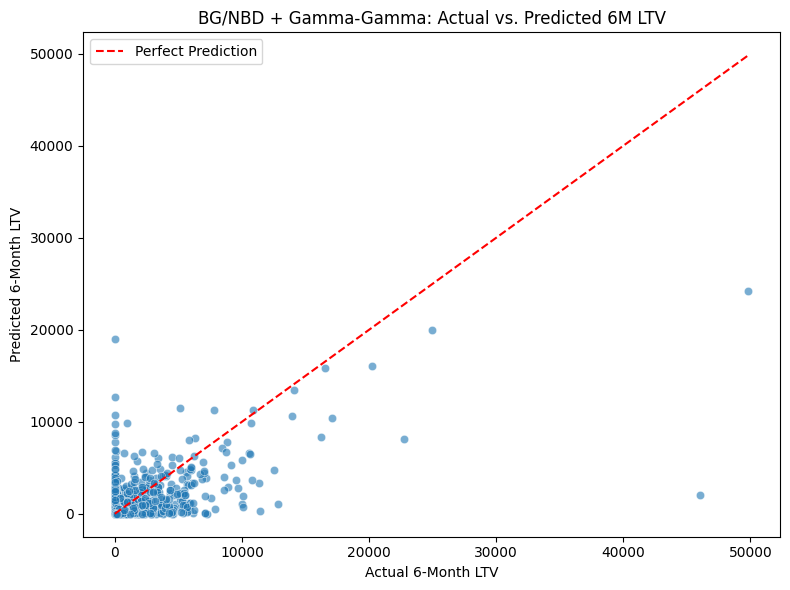

In [48]:
import pandas as pd
import numpy as np
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Assume mart_all_data is your DataFrame with transaction data
# Ensure transaction_date is datetime
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])

# Step 1: Generate summary for LTV modeling
customer_summary = summary_data_from_transaction_data(
    mart_all_data,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='net_revenue',
    observation_period_end=mart_all_data['transaction_date'].max()
)

# Step 2: Clean data for Gamma-Gamma model & convergence

# Remove non-positive monetary values (Gamma-Gamma requires positive monetary_value)
customer_summary = customer_summary[customer_summary['monetary_value'] > 0]

# Cap monetary_value at 99th percentile to reduce outlier impact
cap_monetary = customer_summary['monetary_value'].quantile(0.99)
customer_summary['monetary_value'] = np.minimum(customer_summary['monetary_value'], cap_monetary)

# Cap frequency at a max value (e.g., 20) to avoid extreme frequencies
customer_summary['frequency'] = np.minimum(customer_summary['frequency'], 20)

# Scale recency and T to months for stability (assuming days initially)
customer_summary['recency_scaled'] = customer_summary['recency'] / 30
customer_summary['T_scaled'] = customer_summary['T'] / 30

# Step 3: Fit BG/NBD model with larger penalizer for convergence
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(
    frequency=customer_summary['frequency'],
    recency=customer_summary['recency_scaled'],
    T=customer_summary['T_scaled']
)

# Step 4: Fit Gamma-Gamma model on customers with frequency > 0
returning_customers = customer_summary[customer_summary['frequency'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency'], returning_customers['monetary_value'])

# Step 5: Predict expected purchases and avg monetary value for next 6 months (180 days)
customer_summary['predicted_purchases_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    6,  # 6 months here because we scaled time to months
    customer_summary['frequency'],
    customer_summary['recency_scaled'],
    customer_summary['T_scaled']
)

customer_summary['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    customer_summary['frequency'], customer_summary['monetary_value']
)

# Final predicted LTV for 6 months
customer_summary['predicted_LTV_6m'] = customer_summary['predicted_purchases_6m'] * customer_summary['predicted_avg_value']

# Step 6: Evaluate predictions against actuals for a cutoff date

cutoff_date = pd.Timestamp('2019-04-01')
future_6m_end = cutoff_date + pd.DateOffset(days=180)

# Actual LTV: sum net revenue per customer in 6 months after cutoff
actual_ltv = (
    mart_all_data[
        (mart_all_data['transaction_date'] >= cutoff_date) &
        (mart_all_data['transaction_date'] < future_6m_end)
    ]
    .groupby('customer_id')['net_revenue'].sum()
    .reset_index()
    .rename(columns={'net_revenue': 'actual_LTV_6m'})
)

# Merge actual LTV with prediction summary
eval_df = customer_summary.reset_index()[['customer_id', 'predicted_LTV_6m']].merge(
    actual_ltv, on='customer_id', how='left'
)

# Fill NaN actuals with 0 (no purchases)
eval_df['actual_LTV_6m'] = eval_df['actual_LTV_6m'].fillna(0)

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(eval_df['actual_LTV_6m'], eval_df['predicted_LTV_6m']))
mae = mean_absolute_error(eval_df['actual_LTV_6m'], eval_df['predicted_LTV_6m'])

# Print metrics and means
mean_actual_ltv = eval_df['actual_LTV_6m'].mean()
mean_predicted_ltv = eval_df['predicted_LTV_6m'].mean()

print(f"Mean Actual 6M LTV: ${mean_actual_ltv:,.2f}")
print(f"Mean Predicted 6M LTV: ${mean_predicted_ltv:,.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Step 7: Plot actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x='actual_LTV_6m', y='predicted_LTV_6m', data=eval_df, alpha=0.6)
plt.plot(
    [eval_df['actual_LTV_6m'].min(), eval_df['actual_LTV_6m'].max()],
    [eval_df['actual_LTV_6m'].min(), eval_df['actual_LTV_6m'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
plt.xlabel("Actual 6-Month LTV")
plt.ylabel("Predicted 6-Month LTV")
plt.title("BG/NBD + Gamma-Gamma: Actual vs. Predicted 6M LTV")
plt.legend()
plt.tight_layout()
plt.show()
